# Proyecto

### Importación de librerías.

In [1]:
import pandas as pd
import folium
from folium.plugins import HeatMap

### Extracción y visualización previa de los datos.

In [ ]:
df_datos = pd.read_csv('datos_limpios.csv')
df_datos2 = df_datos.copy()
df_estacion = pd.read_csv('estaciones.csv')

C:\Users\ricro\AppData\Local\Temp\ipykernel_29960\2211946333.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_datos = pd.read_csv('datos_limpios.csv')


In [3]:
df_datos.head(2)

,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
0,52,2015-03-29,35
1,52,2015-03-29,35


In [4]:
df_estacion.head(2)

,station_id,external_id,name,short_name,lat,lon,capacity,rental_methods,electric_bike_surcharge_waiver,is_charging,eightd_has_key_dispenser,has_kiosk,source_last_updated_unix,source_last_updated_utc,source_ttl_seconds
0,1,e961269c-34c4-4b70-8e30-a51aa95a8429,CE-710 Molino del Rey - Glorieta de la Lealtad,710,19.416795,-99.192508,39,KEY|CREDITCARD,False,False,False,True,1775875064,2026-04-11T02:37:44+00:00,10
1,5,3ea89109-d2f3-46eb-9c41-c43742050340,CE-407 Prolongación Xochicalco-General Emilia...,407,19.367266,-99.158656,19,KEY|CREDITCARD,False,False,False,True,1775875064,2026-04-11T02:37:44+00:00,10


### Selección de las columnas necesarias para el análisis.

In [5]:
df_estacion_nombre = df_estacion[['short_name', 'name', 'lat', 'lon']]
df_estacion = df_estacion[['short_name', 'lat', 'lon']]

### Se unen los DataFrame.

In [6]:
# Estación Retiro.
df_final = pd.merge(left = df_datos, right = df_estacion, how = 'inner',
                    left_on = 'Ciclo_Estacion_Retiro', right_on = 'short_name')
df_final = df_final.drop(columns = ['Ciclo_Estacion_Retiro', 'short_name'])
df_final.columns = ['Fecha', 'Ciclo_Estacion_Arribo', 'Latitud_retiro', 'Longitud_retiro']

# Estación Arribo.
df_final = pd.merge(left = df_final, right = df_estacion, how = 'inner',
                    left_on = 'Ciclo_Estacion_Arribo', right_on = 'short_name')
df_final = df_final.drop(columns = ['Ciclo_Estacion_Arribo', 'short_name'])
df_final.columns = ['Fecha', 'Latitud_retiro', 'Longitud_retiro', 'Latitud_arribo', 'Longitud_arribo']

# Se ve el encabezado.
df_final.head(2)

,Fecha,Latitud_retiro,Longitud_retiro,Latitud_arribo,Longitud_arribo
0,2022-04-11,19.437165,-99.207931,19.434182,-99.189835
1,2022-04-12,19.437165,-99.207931,19.434182,-99.189835


### Se crean los DataFrames de conteo.

In [7]:
conteo_retiro = (df_final.groupby(['Latitud_retiro', 'Longitud_retiro']).size().reset_index(name='cantidad_registros'))
conteo_retiro.head()

,Latitud_retiro,Longitud_retiro,cantidad_registros
0,19.344107,-99.155933,562
1,19.344275,-99.149988,680
2,19.344782,-99.163584,309
3,19.344842,-99.157702,321
4,19.345966,-99.172975,325


In [8]:
conteo_arribo = (df_final.groupby(['Latitud_arribo', 'Longitud_arribo']).size().reset_index(name='cantidad_registros'))
conteo_arribo.head()

,Latitud_arribo,Longitud_arribo,cantidad_registros
0,19.344107,-99.155933,626
1,19.344275,-99.149988,807
2,19.344782,-99.163584,315
3,19.344842,-99.157702,373
4,19.345966,-99.172975,326


### Se esablece las coordenadas centrales del mapa y se instancia el mismo.

In [9]:
# Centro de la Ciudad de México
centro_cdmx = [19.4326, -99.1332]

mapa = folium.Map(location=centro_cdmx, zoom_start=11, tiles="CartoDB positron")

### Mapa de retiro.

In [10]:
datos_heatmap_retiro = conteo_retiro[["Latitud_retiro", "Longitud_retiro", "cantidad_registros"]].values.tolist()
HeatMap(data=datos_heatmap_retiro, radius=18, blur=12, max_zoom=13, min_opacity=0.35,).add_to(mapa)

# Guardar mapa en HTML
mapa.save("mapa_retiro.html")

### Mapa de arribo.

In [11]:
datos_heatmap_arribo = conteo_arribo[["Latitud_arribo", "Longitud_arribo", "cantidad_registros"]].values.tolist()
HeatMap(data=datos_heatmap_arribo, radius=18, blur=12, max_zoom=13, min_opacity=0.35,).add_to(mapa)

# Guardar mapa en HTML
mapa.save("mapa_arribo.html")

### Top 10 estaciones de retiro y arribo.

In [12]:
top_10_retiro = conteo_retiro.sort_values(by = 'cantidad_registros', ascending = False).head(10)
top_10_retiro = top_10_retiro.merge(df_estacion_nombre, how = 'inner', left_on = ['Latitud_retiro', 'Longitud_retiro'], right_on = ['lat', 'lon'])

In [13]:
top_10_arribo = conteo_arribo.sort_values(by = 'cantidad_registros', ascending = False).head(10)
top_10_arribo = top_10_arribo.merge(df_estacion_nombre, how = 'inner', left_on = ['Latitud_arribo', 'Longitud_arribo'], right_on = ['lat', 'lon'])

In [14]:
top_10_retiro[['name', 'cantidad_registros']]

,name,cantidad_registros
0,CE-271-272 Jesús García - Carlos J. Meneses,8008
1,CE-194 Circuito Mahatma Gandhi-Reforma,7062
2,CE-027 Reforma- Havre,5514
3,CE-192-193 Rubén Darío.Reforma,5338
4,CE-195 Reforma-Circuito Mahatma Gandhi,4931
5,CE-043 Revillagigedo - Juárez,4930
6,CE-237-238 Andrés Bello-George Eliot,4465
7,CE-041 Reforma - Av. de la República,4352
8,CE-014 Reforma - Río de Plata,4338
9,CE-064 Sonora - Ámsterdam,4285


In [15]:
top_10_arribo[['name', 'cantidad_registros']]

,name,cantidad_registros
0,CE-271-272 Jesús García - Carlos J. Meneses,12213
1,CE-194 Circuito Mahatma Gandhi-Reforma,7036
2,CE-014 Reforma - Río de Plata,5623
3,CE-043 Revillagigedo - Juárez,5621
4,CE-027 Reforma- Havre,5564
5,CE-192-193 Rubén Darío.Reforma,4842
6,CE-195 Reforma-Circuito Mahatma Gandhi,4806
7,CE-242 Pról. Moliere-Miguel de Cervantes Saavedra,4514
8,CE-134 Álvaro Obregón-Orizaba,4414
9,CE-064 Sonora - Ámsterdam,4413


### KMEANS

In [50]:
# Copia del df
df_cluster = df_datos2.copy()

# Formato de fecha
df_cluster['Fecha'] = pd.to_datetime(df_cluster['Fecha_Retiro'])

# Conteo por fechas.
df_cluster = (df_cluster.groupby('Fecha').size().reset_index(name='cantidad_registros'))

df_cluster.head(2)

,Fecha,cantidad_registros
0,2015-03-29,11915
1,2015-03-30,29726


In [51]:
# Entre semana o fin de semana.
df_cluster['tipo_dia'] = df_cluster['Fecha'].dt.dayofweek.apply(lambda x: 1 if x in [4, 5, 6] else 0)

# Día de la semana en número
df_cluster['dia_numero'] = df_cluster['Fecha'].dt.dayofweek

# Año
df_cluster['anio'] = df_cluster['Fecha'].dt.year

# Etiqueta pandemia
df_cluster['etiqueta_pandemia'] = df_cluster['anio'].apply(lambda x: 'post_pandemia' if x >= 2020 else 'pre_pandemia')

df_cluster.head(2)


,Fecha,cantidad_registros,tipo_dia,dia_numero,anio,etiqueta_pandemia
0,2015-03-29,11915,1,6,2015,pre_pandemia
1,2015-03-30,29726,0,0,2015,pre_pandemia


In [48]:
# Columnas a usar
df_cluster = df_cluster[['cantidad_registros', 'tipo_dia', 'etiqueta_pandemia']]
df_cluster.head(2)


,cantidad_registros,tipo_dia,etiqueta_pandemia
0,11915,1,pre_pandemia
1,29726,0,pre_pandemia


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    completeness_score,
    silhouette_score
)

In [54]:
df_km = df_cluster.copy()
# Eliminar nulos.
df_km = df_km.dropna().reset_index(drop=True)

# Variables de entrada y etiqueta real
X = df_km[['cantidad_registros', 'tipo_dia']]
y = df_km['etiqueta_pandemia']

# Escalado de datos
scaler = StandardScaler(with_mean=True,with_std=True)
X_scaled = scaler.fit_transform(X)

In [55]:
# Modelo
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    max_iter=300,
    tol=1e-4,
    random_state=42,
    algorithm='lloyd'
)

df_km['cluster'] = kmeans.fit_predict(X_scaled)

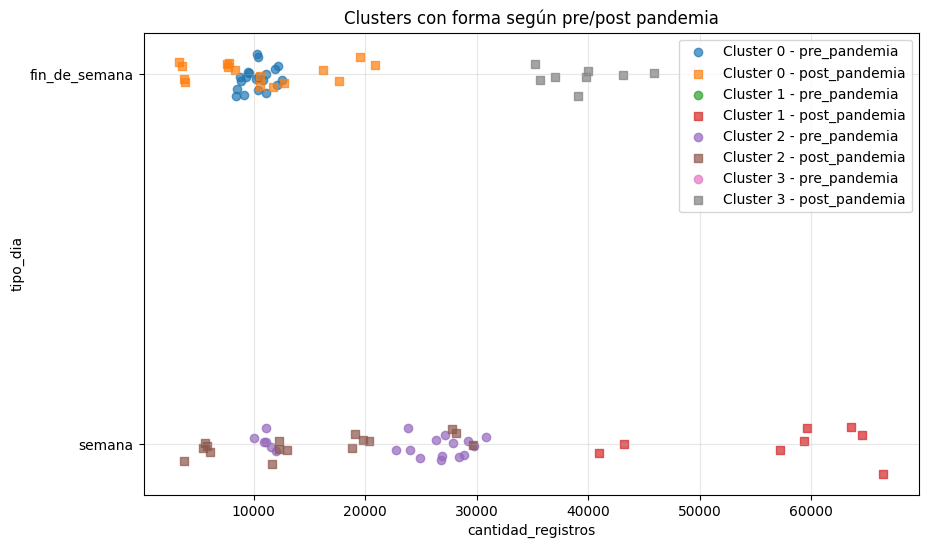

In [56]:
np.random.seed(42)
jitter = np.random.normal(0, 0.03, size=len(df_km))

marcadores = {
    'pre_pandemia': 'o',    # círculo
    'post_pandemia': 's'    # cuadrado
}

plt.figure(figsize=(10, 6))

for cluster in sorted(df_km['cluster'].unique()):
    for etiqueta in df_km['etiqueta_pandemia'].unique():
        mask = (df_km['cluster'] == cluster) & (df_km['etiqueta_pandemia'] == etiqueta)
        
        plt.scatter(
            df_km.loc[mask, 'cantidad_registros'],
            df_km.loc[mask, 'tipo_dia'] + jitter[mask],
            alpha=0.7,
            marker=marcadores[etiqueta],
            label=f'Cluster {cluster} - {etiqueta}'
        )

plt.xlabel('cantidad_registros')
plt.ylabel('tipo_dia')
plt.yticks([0, 1], ['semana', 'fin_de_semana'])
plt.title('Clusters con forma según pre/post pandemia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

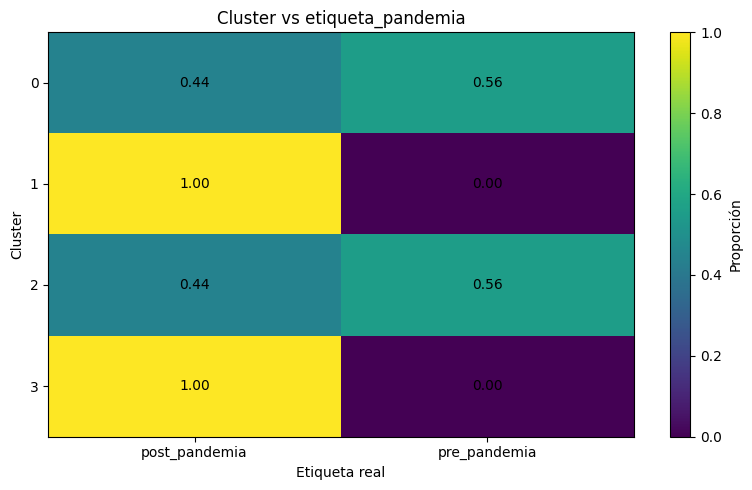

In [59]:
matriz_normalizada = pd.crosstab(
    df_km['cluster'],
    df_km['etiqueta_pandemia'],
    normalize='index'
)

plt.figure(figsize=(8, 5))
plt.imshow(matriz_normalizada.values, aspect='auto')

plt.title('Cluster vs etiqueta_pandemia')
plt.xlabel('Etiqueta real')
plt.ylabel('Cluster')
plt.xticks(range(len(matriz_normalizada.columns)), matriz_normalizada.columns)
plt.yticks(range(len(matriz_normalizada.index)), matriz_normalizada.index)

for i in range(matriz_normalizada.shape[0]):
    for j in range(matriz_normalizada.shape[1]):
        plt.text(
            j, i,
            f"{matriz_normalizada.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.colorbar(label='Proporción')
plt.tight_layout()
plt.show()